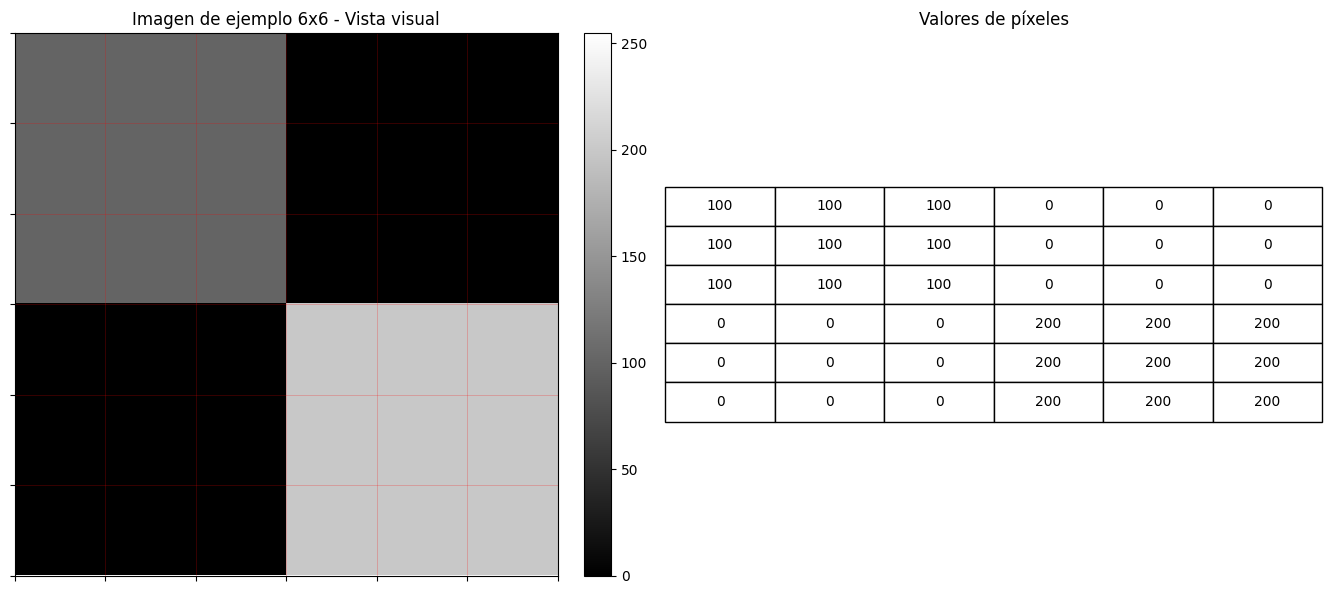

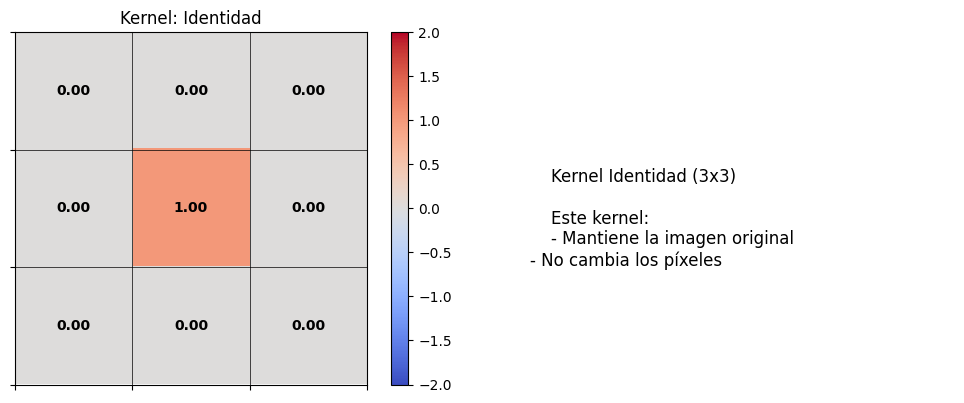

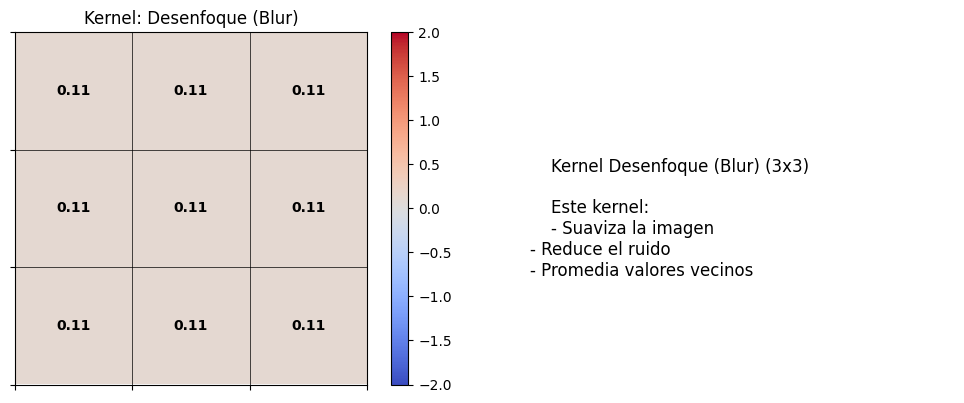

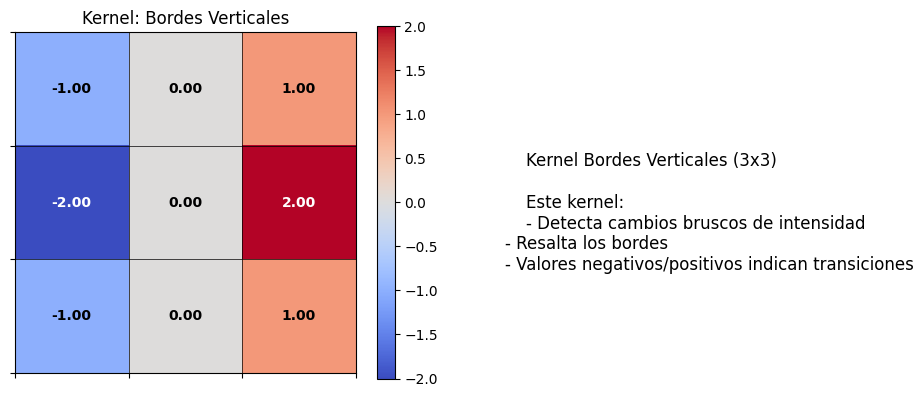

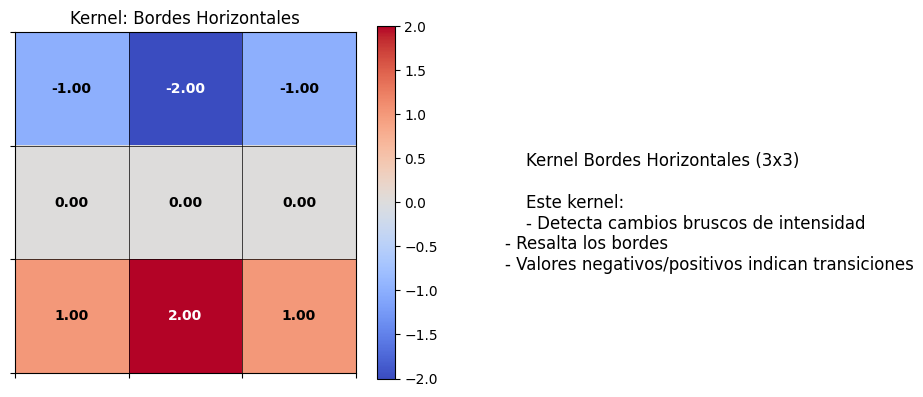

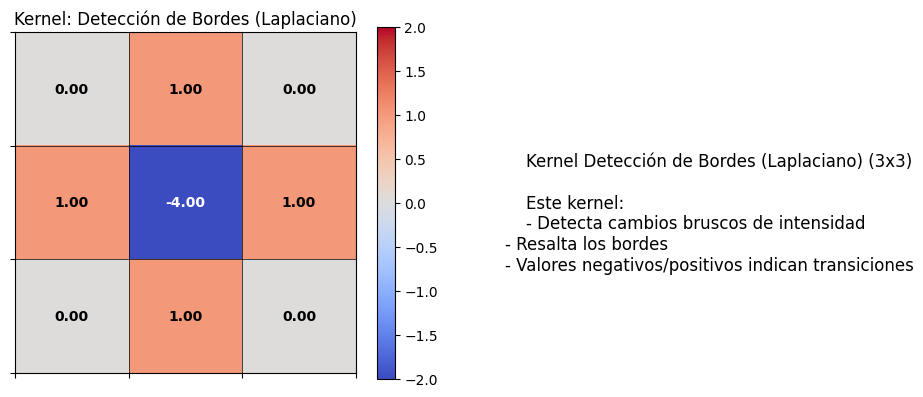

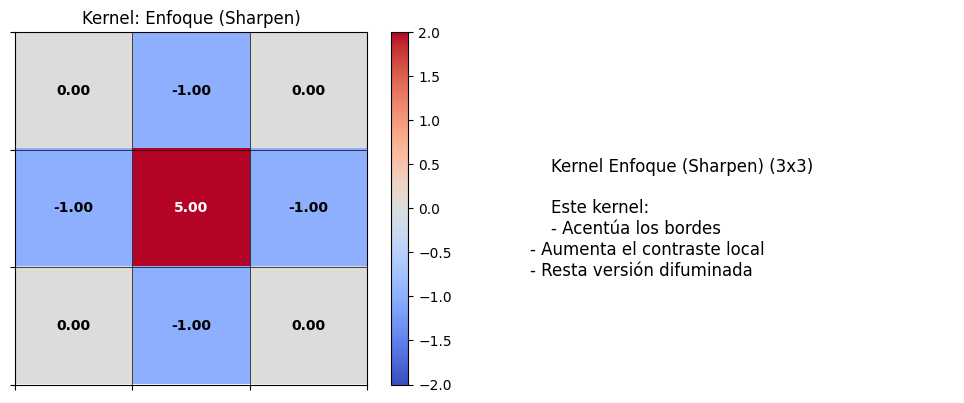

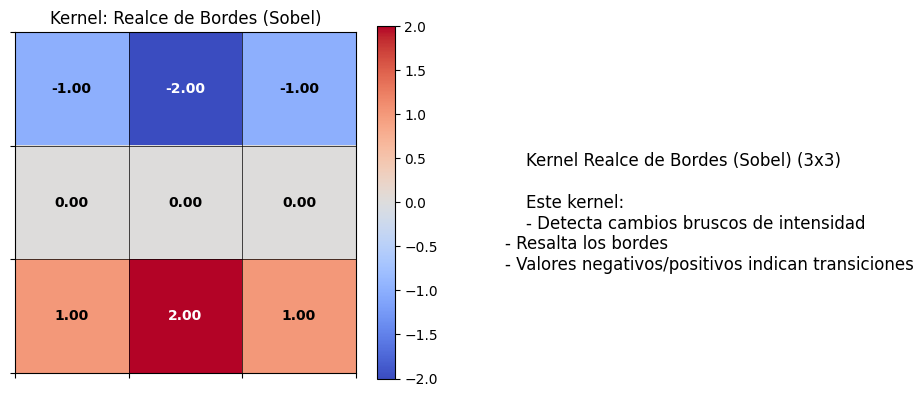

Ejemplo de convolución paso a paso con imagen simple:


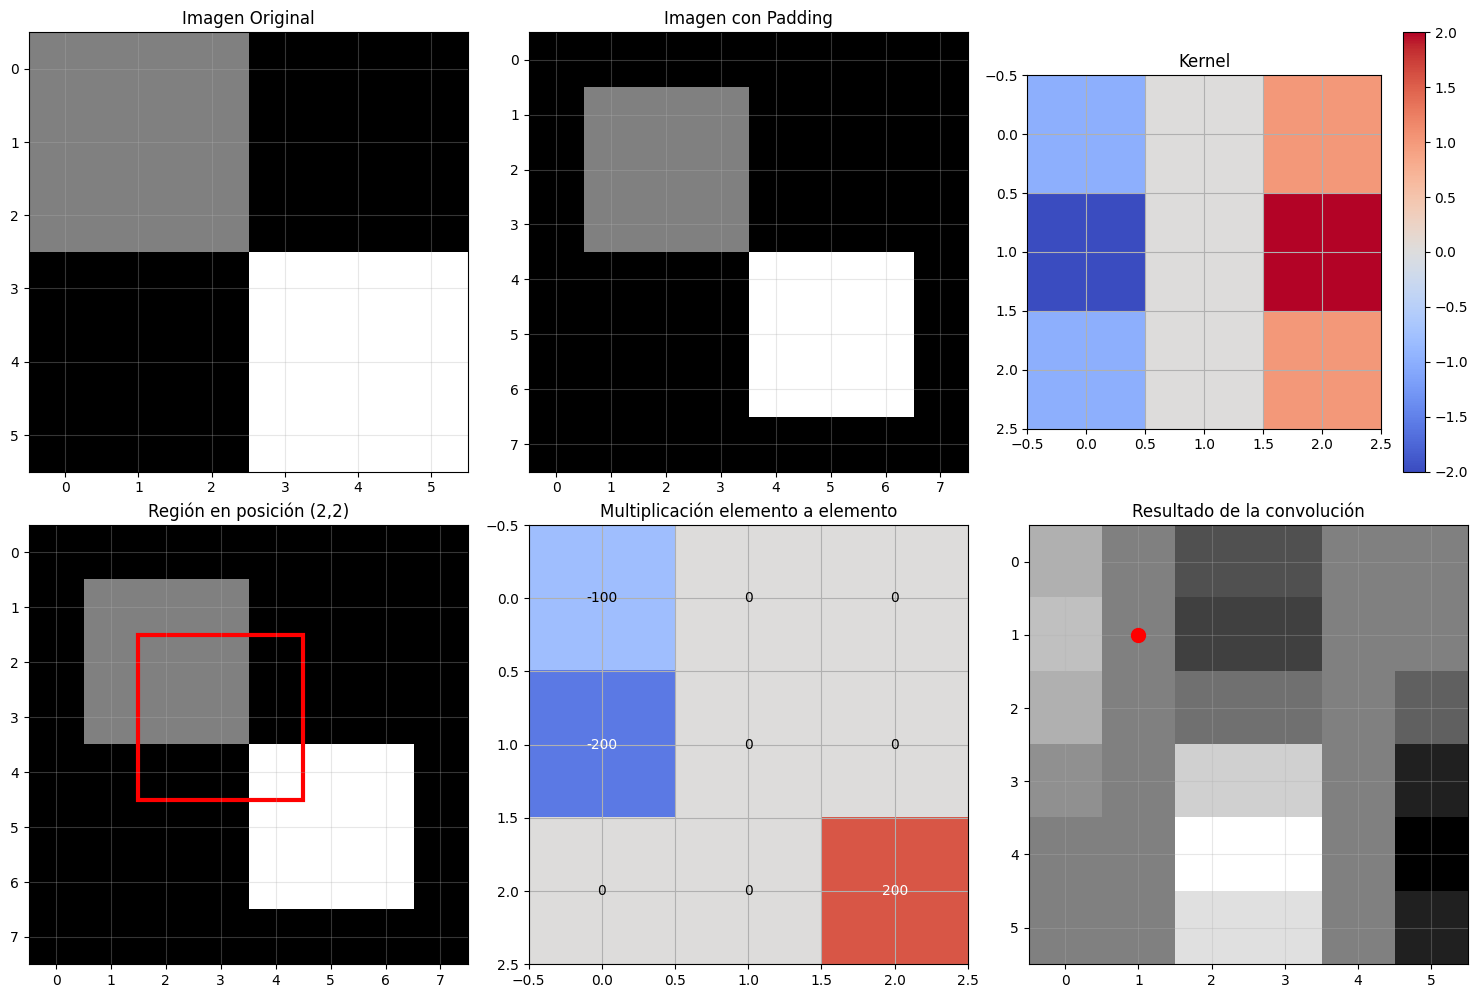


CÁLCULO DETALLADO:
Región extraída:
[[100 100   0]
 [100 100   0]
 [  0   0 200]]

Kernel:
[[-1  0  1]
 [-2  0  2]
 [-1  0  1]]

Multiplicación elemento a elemento:
[[-100    0    0]
 [-200    0    0]
 [   0    0  200]]

Suma de todos los valores: -100.00

Valor en posición (1,1) del resultado: 0.00
Creando imagen de ejemplo...
Aplicando diferentes filtros a imagen real:


[ WARN:0@67.914] global loadsave.cpp:275 findDecoder imread_('sample_image.jpg'): can't open/read file: check file path/integrity


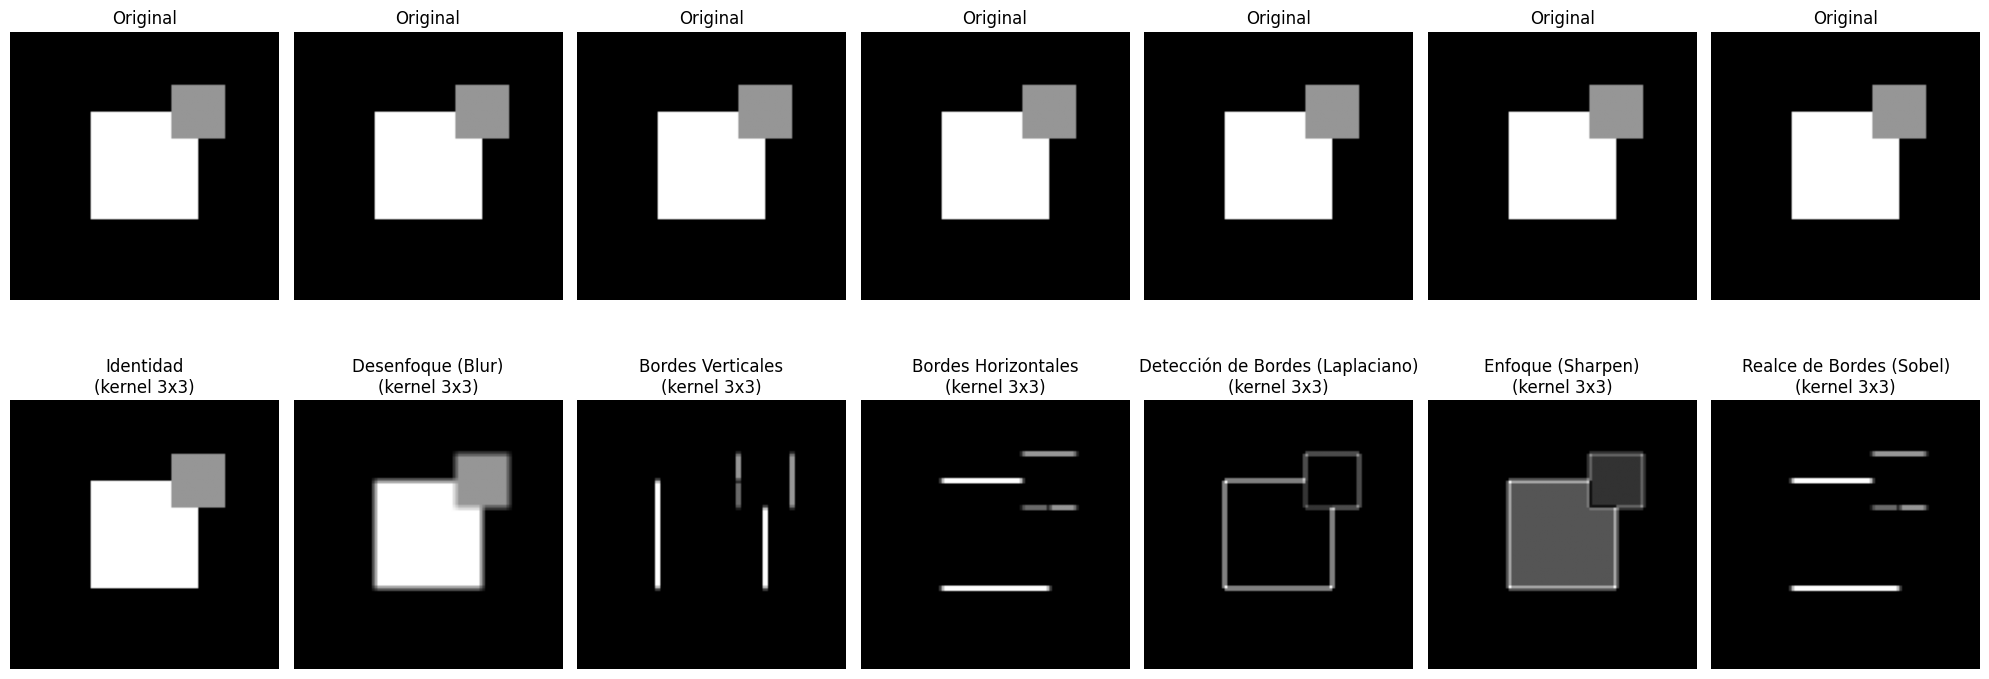

ANÁLISIS DE RESULTADOS:

Identidad:
  - Valor mínimo: 0.00
  - Valor máximo: 255.00
  - Rango: 255.00

Desenfoque (Blur):
  - Valor mínimo: 0.00
  - Valor máximo: 255.00
  - Rango: 255.00

Bordes Verticales:
  - Valor mínimo: -1020.00
  - Valor máximo: 1020.00
  - Rango: 2040.00

Bordes Horizontales:
  - Valor mínimo: -1020.00
  - Valor máximo: 1020.00
  - Rango: 2040.00

Detección de Bordes (Laplaciano):
  - Valor mínimo: -510.00
  - Valor máximo: 405.00
  - Rango: 915.00

Enfoque (Sharpen):
  - Valor mínimo: -405.00
  - Valor máximo: 765.00
  - Rango: 1170.00

Realce de Bordes (Sobel):
  - Valor mínimo: -1020.00
  - Valor máximo: 1020.00
  - Rango: 2040.00


Usa los sliders para crear tu propio kernel y haz click en 'Aplicar Filtro'
Combinando filtros para extraer mejores características:


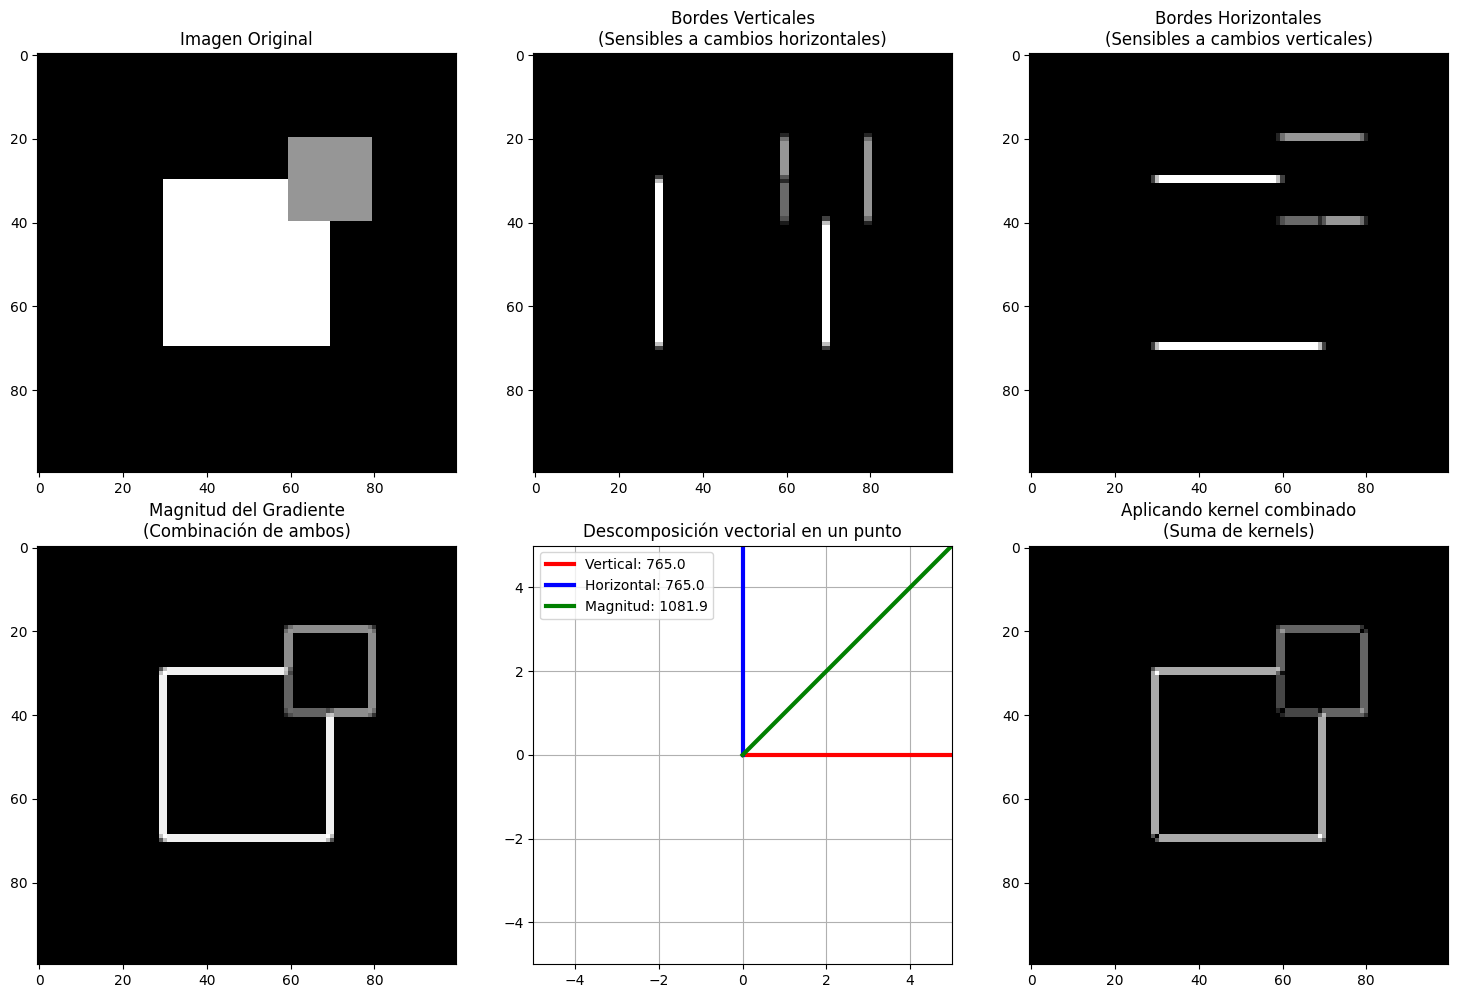


CONCLUSIÓN:
Podemos combinar filtros de dos maneras:
1. Aplicar filtros por separado y combinar resultados (ej: magnitud del gradiente)
2. Sumar kernels primero y aplicar una sola convolución

En redes neuronales convolucionales, los kernels se aprenden automáticamente
para combinar características de manera óptima para la tarea específica.


/var/folders/8j/f0xtldm91_1c2bpdr69fxgzw0000gn/T/ipykernel_67313/3923633705.py:592: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/eugenio/Documents/Computer_Vision/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


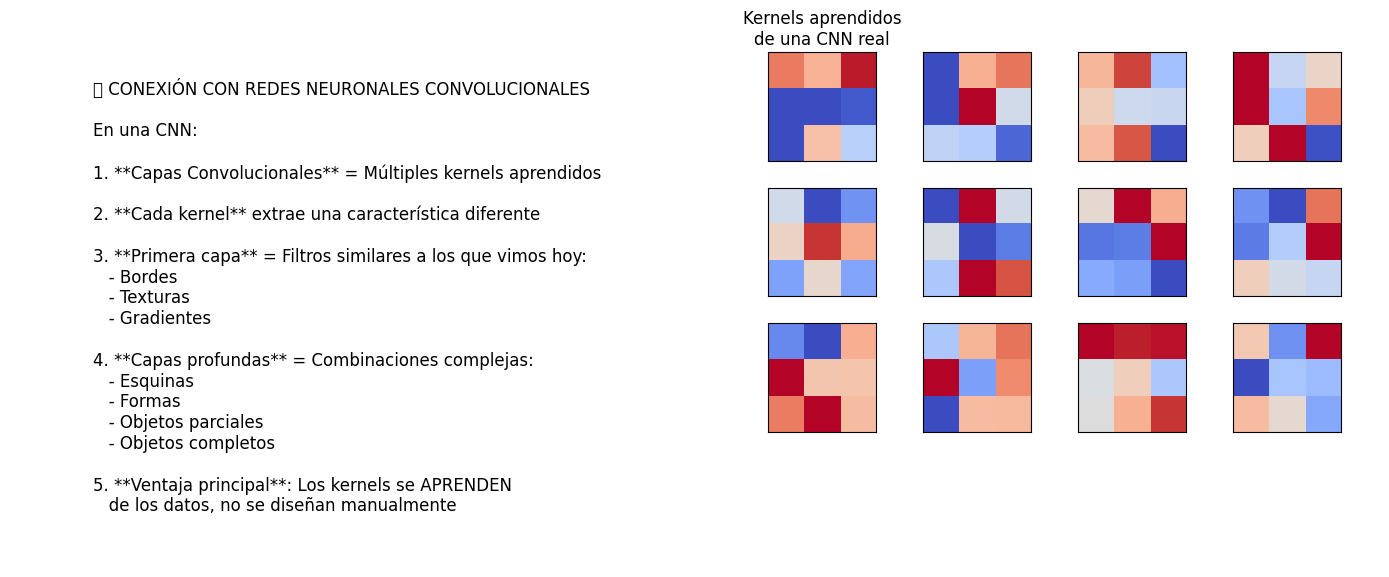


PARA LA PRÓXIMA CLASE:
1. ¿Cómo se aprenden estos kernels automáticamente?
2. ¿Cómo combinar muchas capas convolucionales?
3. ¿Cómo usar estas características para clasificación?
🎯 RESUMEN DE LA CLASE:

1. Las imágenes son matrices/tensores de números
2. Los filtros/kernels son matrices pequeñas que se deslizan sobre la imagen
3. La convolución es la operación de aplicar un kernel a una imagen
4. Diferentes kernels extraen diferentes características:
   - Filtros de bordes: detectan cambios bruscos
   - Filtros de desenfoque: suavizan la imagen
   - Filtros de enfoque: aumentan el contraste local
5. Podemos combinar filtros para extraer mejores características
6. En CNNs, estos kernels se aprenden automáticamente

📚 RECURSOS ADICIONALES:
- OpenCV documentation: cv2.filter2D()
- NumPy: operaciones de álgebra lineal
- Scipy: ndimage.convolve()

💻 EN EL LABORATORIO: Implementarás estos filtros manualmente


In [2]:
# notebook_clase_filtros_convolucion.ipynb

# %% [markdown]
# # 🖼️ Unidad 1: Fundamentos de Visión por Computador - Filtros y Convoluciones
# 
# **Objetivos de aprendizaje:**
# - Entender las imágenes como tensores numéricos
# - Comprender el concepto de filtros/kernels en procesamiento de imágenes
# - Aplicar operaciones de convolución manualmente
# - Visualizar cómo diferentes kernels extraen diferentes características

# %% [markdown]
# ## 1. Configuración inicial

# %%
import numpy as np
import cv2
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from scipy import ndimage
import ipywidgets as widgets
from IPython.display import display, clear_output

# Configuración de matplotlib para mejor visualización
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['image.cmap'] = 'gray'

# %% [markdown]
# ## 2. Las imágenes como tensores

# %%
# Creamos una imagen de ejemplo simple para visualizar
simple_image = np.array([
    [100, 100, 100, 0, 0, 0],
    [100, 100, 100, 0, 0, 0],
    [100, 100, 100, 0, 0, 0],
    [0, 0, 0, 200, 200, 200],
    [0, 0, 0, 200, 200, 200],
    [0, 0, 0, 200, 200, 200]
], dtype=np.uint8)

# %%
def visualize_pixels(image, title="Imagen como matriz de píxeles"):
    fig, ax = plt.subplots(1, 2, figsize=(14, 6))
    
    # Mostrar como imagen
    im = ax[0].imshow(image, cmap='gray', vmin=0, vmax=255)
    ax[0].set_title(f'{title} - Vista visual')
    ax[0].grid(True, which='both', color='red', linestyle='-', linewidth=0.5, alpha=0.3)
    ax[0].set_xticks(np.arange(-0.5, image.shape[1], 1))
    ax[0].set_yticks(np.arange(-0.5, image.shape[0], 1))
    ax[0].set_xticklabels([])
    ax[0].set_yticklabels([])
    
    # Mostrar valores numéricos
    ax[1].axis('tight')
    ax[1].axis('off')
    
    # Crear tabla con valores
    table_data = []
    for i in range(image.shape[0]):
        row = []
        for j in range(image.shape[1]):
            row.append(str(image[i, j]))
        table_data.append(row)
    
    table = ax[1].table(cellText=table_data, loc='center', cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 2)
    ax[1].set_title('Valores de píxeles')
    
    plt.colorbar(im, ax=ax[0], orientation='vertical', fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

# %%
visualize_pixels(simple_image, "Imagen de ejemplo 6x6")

# %% [markdown]
# ## 3. ¿Qué es un filtro/kernel?

# %%
# Definimos varios kernels/filtros importantes
kernels = {
    'Identidad': np.array([
        [0, 0, 0],
        [0, 1, 0],
        [0, 0, 0]
    ]),
    
    'Desenfoque (Blur)': np.array([
        [1, 1, 1],
        [1, 1, 1],
        [1, 1, 1]
    ]) / 9,
    
    'Bordes Verticales': np.array([
        [-1, 0, 1],
        [-2, 0, 2],
        [-1, 0, 1]
    ]),
    
    'Bordes Horizontales': np.array([
        [-1, -2, -1],
        [0, 0, 0],
        [1, 2, 1]
    ]),
    
    'Detección de Bordes (Laplaciano)': np.array([
        [0, 1, 0],
        [1, -4, 1],
        [0, 1, 0]
    ]),
    
    'Enfoque (Sharpen)': np.array([
        [0, -1, 0],
        [-1, 5, -1],
        [0, -1, 0]
    ]),
    
    'Realce de Bordes (Sobel)': np.array([
        [-1, -2, -1],
        [0, 0, 0],
        [1, 2, 1]
    ])
}

# %%
def visualize_kernel(kernel, name):
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    
    # Mostrar kernel como imagen
    im = ax[0].imshow(kernel, cmap='coolwarm', vmin=-2, vmax=2)
    ax[0].set_title(f'Kernel: {name}')
    ax[0].grid(True, which='both', color='black', linestyle='-', linewidth=0.5)
    ax[0].set_xticks(np.arange(-0.5, kernel.shape[1], 1))
    ax[0].set_yticks(np.arange(-0.5, kernel.shape[0], 1))
    ax[0].set_xticklabels([])
    ax[0].set_yticklabels([])
    
    # Anotar valores
    for i in range(kernel.shape[0]):
        for j in range(kernel.shape[1]):
            ax[0].text(j, i, f'{kernel[i, j]:.2f}', 
                      ha='center', va='center', 
                      color='black' if abs(kernel[i, j]) < 1.5 else 'white',
                      fontweight='bold')
    
    # Explicación visual del kernel
    ax[1].axis('off')
    explanation = f"""
    Kernel {name} ({kernel.shape[0]}x{kernel.shape[1]})
    
    Este kernel:
    """
    
    if name == 'Identidad':
        explanation += "- Mantiene la imagen original\n- No cambia los píxeles"
    elif name == 'Desenfoque (Blur)':
        explanation += "- Suaviza la imagen\n- Reduce el ruido\n- Promedia valores vecinos"
    elif 'Bordes' in name:
        explanation += "- Detecta cambios bruscos de intensidad\n- Resalta los bordes\n- Valores negativos/positivos indican transiciones"
    elif 'Enfoque' in name:
        explanation += "- Acentúa los bordes\n- Aumenta el contraste local\n- Resta versión difuminada"
    
    ax[1].text(0.1, 0.5, explanation, fontsize=12, 
               verticalalignment='center', transform=ax[1].transAxes)
    
    plt.colorbar(im, ax=ax[0])
    plt.tight_layout()
    plt.show()

# %%
# Visualizar cada kernel
for name, kernel in kernels.items():
    visualize_kernel(kernel, name)

# %% [markdown]
# ## 4. Operación de convolución paso a paso

# %%
def convolucion_manual(imagen, kernel, padding=1, stride=1):
    """
    Implementación manual de convolución 2D
    """
    # Añadir padding
    if padding > 0:
        imagen_padded = np.pad(imagen, padding, mode='constant', constant_values=0)
    else:
        imagen_padded = imagen
    
    # Dimensiones
    h, w = imagen_padded.shape
    k_h, k_w = kernel.shape
    
    # Calcular dimensiones de salida
    out_h = (h - k_h) // stride + 1
    out_w = (w - k_w) // stride + 1
    
    # Crear matriz de salida
    output = np.zeros((out_h, out_w))
    
    # Aplicar convolución
    for i in range(0, out_h):
        for j in range(0, out_w):
            # Extraer región de interés
            region = imagen_padded[i*stride:i*stride+k_h, j*stride:j*stride+k_w]
            # Multiplicar elemento por elemento y sumar
            output[i, j] = np.sum(region * kernel)
    
    return output

# %%
def visualizar_convolucion_paso_a_paso(imagen, kernel, paso=1):
    """
    Visualiza la convolución paso a paso
    """
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # 1. Imagen original
    axes[0, 0].imshow(imagen, cmap='gray')
    axes[0, 0].set_title('Imagen Original')
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Imagen con padding
    imagen_padded = np.pad(imagen, 1, mode='constant', constant_values=0)
    axes[0, 1].imshow(imagen_padded, cmap='gray')
    axes[0, 1].set_title('Imagen con Padding')
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. Kernel
    im_kernel = axes[0, 2].imshow(kernel, cmap='coolwarm', vmin=-2, vmax=2)
    axes[0, 2].set_title('Kernel')
    axes[0, 2].grid(True)
    plt.colorbar(im_kernel, ax=axes[0, 2])
    
    # 4. Región actual siendo procesada
    # Simulamos una posición específica
    i, j = 2, 2  # posición ejemplo
    axes[1, 0].imshow(imagen_padded, cmap='gray')
    
    # Resaltar región
    rect = Rectangle((j-0.5, i-0.5), kernel.shape[1], kernel.shape[0], 
                     linewidth=3, edgecolor='r', facecolor='none')
    axes[1, 0].add_patch(rect)
    axes[1, 0].set_title(f'Región en posición ({i},{j})')
    axes[1, 0].grid(True, alpha=0.3)
    
    # 5. Multiplicación elemento por elemento
    region = imagen_padded[i:i+kernel.shape[0], j:j+kernel.shape[1]]
    axes[1, 1].imshow(region * kernel, cmap='coolwarm', vmin=-255, vmax=255)
    axes[1, 1].set_title('Multiplicación elemento a elemento')
    axes[1, 1].grid(True)
    
    # Anotar valores
    for x in range(kernel.shape[0]):
        for y in range(kernel.shape[1]):
            axes[1, 1].text(y, x, f'{region[x,y]*kernel[x,y]:.0f}', 
                           ha='center', va='center', color='white' if abs(region[x,y]*kernel[x,y]) > 128 else 'black')
    
    # 6. Resultado parcial
    resultado_parcial = convolucion_manual(imagen, kernel)
    axes[1, 2].imshow(resultado_parcial, cmap='gray')
    axes[1, 2].set_title('Resultado de la convolución')
    axes[1, 2].grid(True, alpha=0.3)
    
    # Resaltar posición actual en resultado
    if i-1 < resultado_parcial.shape[0] and j-1 < resultado_parcial.shape[1]:
        axes[1, 2].plot(j-1, i-1, 'ro', markersize=10)
    
    plt.tight_layout()
    plt.show()
    
    # Mostrar cálculo matemático
    print("\n" + "="*60)
    print("CÁLCULO DETALLADO:")
    print(f"Región extraída:\n{region}")
    print(f"\nKernel:\n{kernel}")
    print(f"\nMultiplicación elemento a elemento:\n{region * kernel}")
    print(f"\nSuma de todos los valores: {np.sum(region * kernel):.2f}")
    print(f"\nValor en posición ({i-1},{j-1}) del resultado: {resultado_parcial[i-1, j-1]:.2f}")
    print("="*60)

# %%
# Ejemplo con imagen simple
print("Ejemplo de convolución paso a paso con imagen simple:")
visualizar_convolucion_paso_a_paso(simple_image, kernels['Bordes Verticales'])

# %% [markdown]
# ## 5. Aplicación a imagen real

# %%
# Cargar una imagen real
# Puedes usar una imagen local o descargar una de ejemplo
try:
    # Intentar cargar imagen local
    real_image = cv2.imread('sample_image.jpg', cv2.IMREAD_GRAYSCALE)
    if real_image is None:
        # Crear imagen de ejemplo si no hay archivo local
        print("Creando imagen de ejemplo...")
        real_image = np.zeros((100, 100))
        real_image[30:70, 30:70] = 255  # Cuadrado blanco en fondo negro
        real_image[20:40, 60:80] = 150  # Rectángulo gris
        real_image = real_image.astype(np.uint8)
except:
    # Imagen de fallback
    real_image = cv2.imread(cv2.samples.findFile('lena.jpg'), cv2.IMREAD_GRAYSCALE)
    if real_image is None:
        real_image = np.random.randint(0, 255, (100, 100), dtype=np.uint8)

# %%
def aplicar_y_visualizar_filtros(imagen, kernels_dict):
    """
    Aplica múltiples filtros y los visualiza
    """
    n_filtros = len(kernels_dict)
    fig, axes = plt.subplots(2, n_filtros, figsize=(20, 8))
    
    for idx, (nombre, kernel) in enumerate(kernels_dict.items()):
        # Aplicar filtro
        resultado = convolucion_manual(imagen, kernel, padding=1)
        
        # Normalizar para visualización
        resultado_norm = np.abs(resultado)
        resultado_norm = (resultado_norm - resultado_norm.min()) / (resultado_norm.max() - resultado_norm.min() + 1e-8) * 255
        
        # Mostrar resultados
        axes[0, idx].imshow(imagen, cmap='gray')
        axes[0, idx].set_title('Original')
        axes[0, idx].axis('off')
        
        axes[1, idx].imshow(resultado_norm, cmap='gray')
        axes[1, idx].set_title(f'{nombre}\n(kernel {kernel.shape[0]}x{kernel.shape[1]})')
        axes[1, idx].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Mostrar valores extremos
    print("ANÁLISIS DE RESULTADOS:")
    for nombre, kernel in kernels_dict.items():
        resultado = convolucion_manual(imagen, kernel, padding=1)
        print(f"\n{nombre}:")
        print(f"  - Valor mínimo: {resultado.min():.2f}")
        print(f"  - Valor máximo: {resultado.max():.2f}")
        print(f"  - Rango: {resultado.max() - resultado.min():.2f}")

# %%
print("Aplicando diferentes filtros a imagen real:")
aplicar_y_visualizar_filtros(real_image, kernels)

# %% [markdown]
# ## 6. Widget interactivo para explorar kernels

# %%
def crear_widget_interactivo():
    """
    Crea un widget interactivo para explorar kernels personalizados
    """
    # Widgets para definir kernel 3x3
    kernel_widgets = []
    for i in range(3):
        row_widgets = []
        for j in range(3):
            w = widgets.FloatSlider(
                value=0.0,
                min=-2.0,
                max=2.0,
                step=0.1,
                description=f'K[{i},{j}]',
                continuous_update=False
            )
            row_widgets.append(w)
        kernel_widgets.append(row_widgets)
    
    # Widget para imagen
    image_selector = widgets.Dropdown(
        options=['Simple', 'Real', 'Bordes nítidos', 'Gradiente'],
        value='Real',
        description='Imagen:'
    )
    
    # Botón para aplicar
    apply_button = widgets.Button(description="Aplicar Filtro")
    
    # Contenedor
    kernel_box = widgets.VBox([
        widgets.HBox(kernel_widgets[0]),
        widgets.HBox(kernel_widgets[1]),
        widgets.HBox(kernel_widgets[2]),
        image_selector,
        apply_button
    ])
    
    # Función de callback
    def on_apply_clicked(b):
        clear_output(wait=True)
        display(kernel_box)
        
        # Crear kernel desde widgets
        kernel = np.array([[w.value for w in row] for row in kernel_widgets])
        
        # Seleccionar imagen
        if image_selector.value == 'Simple':
            img = simple_image
        elif image_selector.value == 'Bordes nítidos':
            img = np.zeros((50, 50))
            img[10:20, 10:40] = 255  # Barra horizontal
            img[30:40, 10:40] = 255  # Barra horizontal
        elif image_selector.value == 'Gradiente':
            img = np.tile(np.linspace(0, 255, 50), (50, 1)).T.astype(np.uint8)
        else:
            img = real_image
        
        # Aplicar y visualizar
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        
        # Kernel
        im1 = axes[0].imshow(kernel, cmap='coolwarm', vmin=-2, vmax=2)
        axes[0].set_title('Kernel Personalizado')
        axes[0].grid(True)
        for i in range(3):
            for j in range(3):
                axes[0].text(j, i, f'{kernel[i,j]:.1f}', 
                           ha='center', va='center',
                           color='white' if abs(kernel[i,j]) > 1 else 'black')
        
        # Imagen original
        axes[1].imshow(img, cmap='gray')
        axes[1].set_title('Imagen Original')
        axes[1].axis('off')
        
        # Resultado
        resultado = convolucion_manual(img, kernel, padding=1)
        resultado_norm = (resultado - resultado.min()) / (resultado.max() - resultado.min() + 1e-8) * 255
        axes[2].imshow(resultado_norm, cmap='gray')
        axes[2].set_title('Resultado de Convolución')
        axes[2].axis('off')
        
        plt.colorbar(im1, ax=axes[0])
        plt.tight_layout()
        plt.show()
        
        # Análisis
        print("ANÁLISIS DEL KERNEL:")
        print(f"Suma de elementos: {kernel.sum():.2f}")
        print(f"¿Conserva brillo? {'Sí' if abs(kernel.sum() - 1.0) < 0.1 else 'No'}")
        print(f"¿Detecta bordes? {'Posiblemente' if (kernel.min() < -0.5 and kernel.max() > 0.5) else 'Probablemente no'}")
    
    apply_button.on_click(on_apply_clicked)
    
    return kernel_box

# %%
# Solo ejecutar si estamos en un entorno con widgets
try:
    interactive_widget = crear_widget_interactivo()
    display(interactive_widget)
    print("Usa los sliders para crear tu propio kernel y haz click en 'Aplicar Filtro'")
except:
    print("Los widgets no están disponibles en este entorno")

# %% [markdown]
# ## 7. Combinación de filtros

# %%
def combinar_filtros(imagen):
    """
    Muestra cómo combinar filtros para extraer diferentes características
    """
    # Aplicar filtros de bordes
    bordes_v = convolucion_manual(imagen, kernels['Bordes Verticales'])
    bordes_h = convolucion_manual(imagen, kernels['Bordes Horizontales'])
    
    # Combinar (magnitud del gradiente)
    magnitud = np.sqrt(bordes_v**2 + bordes_h**2)
    
    # Normalizar para visualización
    bordes_v_norm = np.abs(bordes_v) / np.abs(bordes_v).max() * 255
    bordes_h_norm = np.abs(bordes_h) / np.abs(bordes_h).max() * 255
    magnitud_norm = magnitud / magnitud.max() * 255
    
    # Visualizar
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    axes[0, 0].imshow(imagen, cmap='gray')
    axes[0, 0].set_title('Imagen Original')
    
    axes[0, 1].imshow(bordes_v_norm, cmap='gray')
    axes[0, 1].set_title('Bordes Verticales\n(Sensibles a cambios horizontales)')
    
    axes[0, 2].imshow(bordes_h_norm, cmap='gray')
    axes[0, 2].set_title('Bordes Horizontales\n(Sensibles a cambios verticales)')
    
    axes[1, 0].imshow(magnitud_norm, cmap='gray')
    axes[1, 0].set_title('Magnitud del Gradiente\n(Combinación de ambos)')
    
    # Mostrar cómo se calcula en un punto específico
    punto_x, punto_y = 30, 30
    axes[1, 1].plot([0, bordes_v[punto_x, punto_y]], [0, 0], 'r-', linewidth=3, label=f'Vertical: {bordes_v[punto_x, punto_y]:.1f}')
    axes[1, 1].plot([0, 0], [0, bordes_h[punto_x, punto_y]], 'b-', linewidth=3, label=f'Horizontal: {bordes_h[punto_x, punto_y]:.1f}')
    axes[1, 1].plot([0, bordes_v[punto_x, punto_y]], [0, bordes_h[punto_x, punto_y]], 'g-', linewidth=3, 
                    label=f'Magnitud: {magnitud[punto_x, punto_y]:.1f}')
    axes[1, 1].set_xlim(-5, 5)
    axes[1, 1].set_ylim(-5, 5)
    axes[1, 1].grid(True)
    axes[1, 1].set_title('Descomposición vectorial en un punto')
    axes[1, 1].legend()
    axes[1, 1].set_aspect('equal')
    
    # Filtro combinado manualmente
    kernel_combinado = kernels['Bordes Verticales'] + kernels['Bordes Horizontales']
    resultado_combinado = convolucion_manual(imagen, kernel_combinado)
    resultado_combinado_norm = np.abs(resultado_combinado) / np.abs(resultado_combinado).max() * 255
    
    axes[1, 2].imshow(resultado_combinado_norm, cmap='gray')
    axes[1, 2].set_title('Aplicando kernel combinado\n(Suma de kernels)')
    
    plt.tight_layout()
    plt.show()
    
    print("\nCONCLUSIÓN:")
    print("Podemos combinar filtros de dos maneras:")
    print("1. Aplicar filtros por separado y combinar resultados (ej: magnitud del gradiente)")
    print("2. Sumar kernels primero y aplicar una sola convolución")
    print("\nEn redes neuronales convolucionales, los kernels se aprenden automáticamente")
    print("para combinar características de manera óptima para la tarea específica.")

# %%
print("Combinando filtros para extraer mejores características:")
combinar_filtros(real_image)

# %% [markdown]
# ## 8. Conexión con Redes Neuronales Convolucionales (CNNs)

# %%
def visualizar_conexion_cnns():
    """
    Muestra cómo se relacionan estos conceptos con las CNNs
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Visualización de múltiples filtros en CNNs
    axes[0].axis('off')
    cnn_text = """
    🔗 CONEXIÓN CON REDES NEURONALES CONVOLUCIONALES
    
    En una CNN:
    
    1. **Capas Convolucionales** = Múltiples kernels aprendidos
    
    2. **Cada kernel** extrae una característica diferente
    
    3. **Primera capa** = Filtros similares a los que vimos hoy:
       - Bordes
       - Texturas
       - Gradientes
    
    4. **Capas profundas** = Combinaciones complejas:
       - Esquinas
       - Formas
       - Objetos parciales
       - Objetos completos
    
    5. **Ventaja principal**: Los kernels se APRENDEN
       de los datos, no se diseñan manualmente
    """
    axes[0].text(0.1, 0.5, cnn_text, fontsize=12, 
                verticalalignment='center', transform=axes[0].transAxes)
    
    # Ejemplo de aprendizaje de kernels
    kernel_ejemplos = [
        np.random.randn(3, 3) for _ in range(12)
    ]
    
    # Crear una cuadrícula de kernels
    for idx, kernel in enumerate(kernel_ejemplos):
        row = idx // 4
        col = idx % 4
        ax = axes[1].inset_axes([col*0.25, 0.75 - row*0.25, 0.2, 0.2])
        ax.imshow(kernel, cmap='coolwarm', vmin=-1, vmax=1)
        ax.set_xticks([])
        ax.set_yticks([])
        if idx == 0:
            ax.set_title('Kernels aprendidos\nde una CNN real')
    
    axes[1].set_xlim(0, 1)
    axes[1].set_ylim(0, 1)
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print("\nPARA LA PRÓXIMA CLASE:")
    print("1. ¿Cómo se aprenden estos kernels automáticamente?")
    print("2. ¿Cómo combinar muchas capas convolucionales?")
    print("3. ¿Cómo usar estas características para clasificación?")

# %%
visualizar_conexion_cnns()

# %% [markdown]
# ## 9. Resumen y conclusiones

# %%
print("🎯 RESUMEN DE LA CLASE:")
print("\n1. Las imágenes son matrices/tensores de números")
print("2. Los filtros/kernels son matrices pequeñas que se deslizan sobre la imagen")
print("3. La convolución es la operación de aplicar un kernel a una imagen")
print("4. Diferentes kernels extraen diferentes características:")
print("   - Filtros de bordes: detectan cambios bruscos")
print("   - Filtros de desenfoque: suavizan la imagen")
print("   - Filtros de enfoque: aumentan el contraste local")
print("5. Podemos combinar filtros para extraer mejores características")
print("6. En CNNs, estos kernels se aprenden automáticamente")

print("\n📚 RECURSOS ADICIONALES:")
print("- OpenCV documentation: cv2.filter2D()")
print("- NumPy: operaciones de álgebra lineal")
print("- Scipy: ndimage.convolve()")
print("\n💻 EN EL LABORATORIO: Implementarás estos filtros manualmente")